# Imports

In [1]:
import sys
import os
from pathlib import Path

In [2]:
sys.path.append(os.path.join(os.getcwd(),"..",".."))
sys.path.append(os.path.join(os.getcwd(),"..","..",".."))

In [3]:
import numpy as np
import pandas as pd

In [4]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
from backtester import BackTester

In [8]:
data_store=Path(os.getcwd()).parent.parent.parent/"Prepared_Data_Store"

# Loading Benchmark Data

In [9]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [10]:
benchmark_data=benchmark_data.sp500_returns.sort_index().tz_localize("UTC")

# BackTesting

## Trading Strategy-I

### Here we will long the stocks with higher factor values and short the stocks with lower factor values predicted by Ridge Model-16 with reg_aplha=5000

In [11]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [12]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.01,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge16_factor",
    trading_strategy=trading_strategy
)

In [13]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

In [14]:
LIVE_DATE="2016-02-24"

#### Extracting Information from Zipline Results

In [15]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

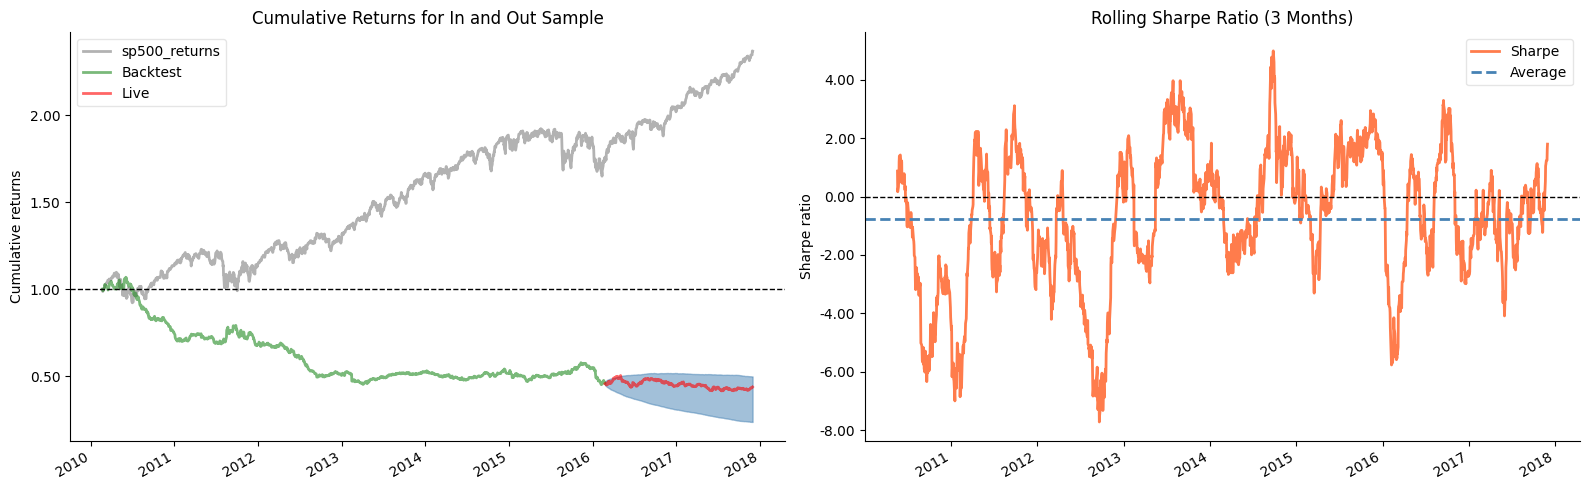

In [16]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    volatility_match=False,
    legend_loc="best",
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,61.07,2010-06-04,2017-07-18,NaT,NaN
1,4.73,2010-05-06,2010-05-13,2010-05-28,17
2,4.29,2010-03-31,2010-04-23,2010-05-05,26
3,3.12,2010-03-04,2010-03-18,2010-03-24,15
4,0.89,2010-02-22,2010-02-24,2010-03-01,6


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.38%,-3.10%,5.02%
Fukushima,0.03%,-0.82%,0.93%
EZB IR Event,-0.10%,-2.26%,1.71%
Flash Crash,-0.79%,-3.05%,0.60%
Apr14,-0.09%,-1.87%,1.05%
Oct14,-0.13%,-1.77%,1.29%
Fall2015,0.05%,-1.85%,2.43%
Recovery,-0.09%,-3.10%,5.02%
New Normal,-0.01%,-7.83%,4.22%


Top 10 long positions of all time,max
sid,
NEM,34.43%
MOS,33.87%
DECK,30.77%
HPQ,30.01%
OKE,29.06%
TSN,27.31%
ERIE,26.62%
NRG,26.37%
WEC,26.00%


Top 10 short positions of all time,max
sid,
NEM,-38.72%
OKE,-33.83%
WTW,-32.12%
AMD,-31.65%
ERIE,-31.50%
WEC,-30.88%
BG,-30.01%
NUE,-29.94%
MOS,-29.59%


Top 10 positions of all time,max
sid,
NEM,38.72%
MOS,33.87%
OKE,33.83%
WTW,32.12%
AMD,31.65%
ERIE,31.50%
WEC,30.88%
DECK,30.77%
BG,30.01%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-581400.51,$-922635.18,$341234.67
Gross profit,$13427791.30,$6521212.22,$6906579.08
Gross loss,$-14009191.81,$-7443847.40,$-6565344.41
Profit factor,$0.96,$0.88,$1.05
Avg. trade net profit,$-7.65,$-24.65,$8.86
Avg. winning trade,$359.91,$367.66,$352.88
Avg. losing trade,$-364.78,$-380.39,$-348.57
Ratio Avg. Win:Avg. Loss,$0.99,$0.97,$1.01
Largest winning trade,$16300.68,$14280.90,$16300.68
Largest losing trade,$-38847.60,$-38847.60,$-21810.25


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 13:55:33.327935968,1 days 16:58:44.498797755,1 days 10:57:36.777307762
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,193 days 00:00:00,193 days 00:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,-0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.03%
Largest winning trade,3.40%,1.98%,3.40%
Largest losing trade,-7.58%,-7.58%,-2.55%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,-0.01%,-0.01%,0.01%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.01%,0.00%,0.01%,0.00%,0.00%,0.01%,-0.00%,0.01%,0.01%,0.02%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.01%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.01%,0.01%,0.01%,0.00%,0.00%,-0.02%,-0.00%,0.01%,0.00%,0.00%,0.02%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.02%,0.01%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,-0.03%,-0.01%,-0.01%,-0.01%,-0.00%,0.00%,-0.03%,-0.01%,0.00%,0.00%,-0.00%,-0.01%,0.02%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.02%,0.00%,0.01%,-0.00%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.02%,0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,-0.00%,-0.01%,-0.01%,-0.01%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,0.01%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.03%,0.00%,-0.00%,-0.00%,-0.00%,0.02%,-0.00%,-0.01%,-0.00%,-0.02%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,-0.01%,0.01%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.02%,0.00%,0.00%,-0.04%,-0.01%,0.00%,-0.04%,0.01%,-0.00%,0.01%,0.00%,0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,0.01%,-0.01%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.01%,0.00%,0.01%,0.01%,-0.05%,-0.01%,0.02%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.01%,0.02%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.02%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.02%,-0.01%,0.01%,-0.00%,-0.03%,-0.01%,0.01%,0.01%,-0.00%,0.00%,0.01%,-0.01%,0.00%,-0.00%,-0.01%,

Profitability (PnL / PnL total) per name,
symbol,
RMD,10.83%
MU,8.74%
STZ,7.99%
RF,6.99%
VRTX,6.72%
AMD,5.61%
WDC,5.54%
NRG,5.09%
IPG,5.04%


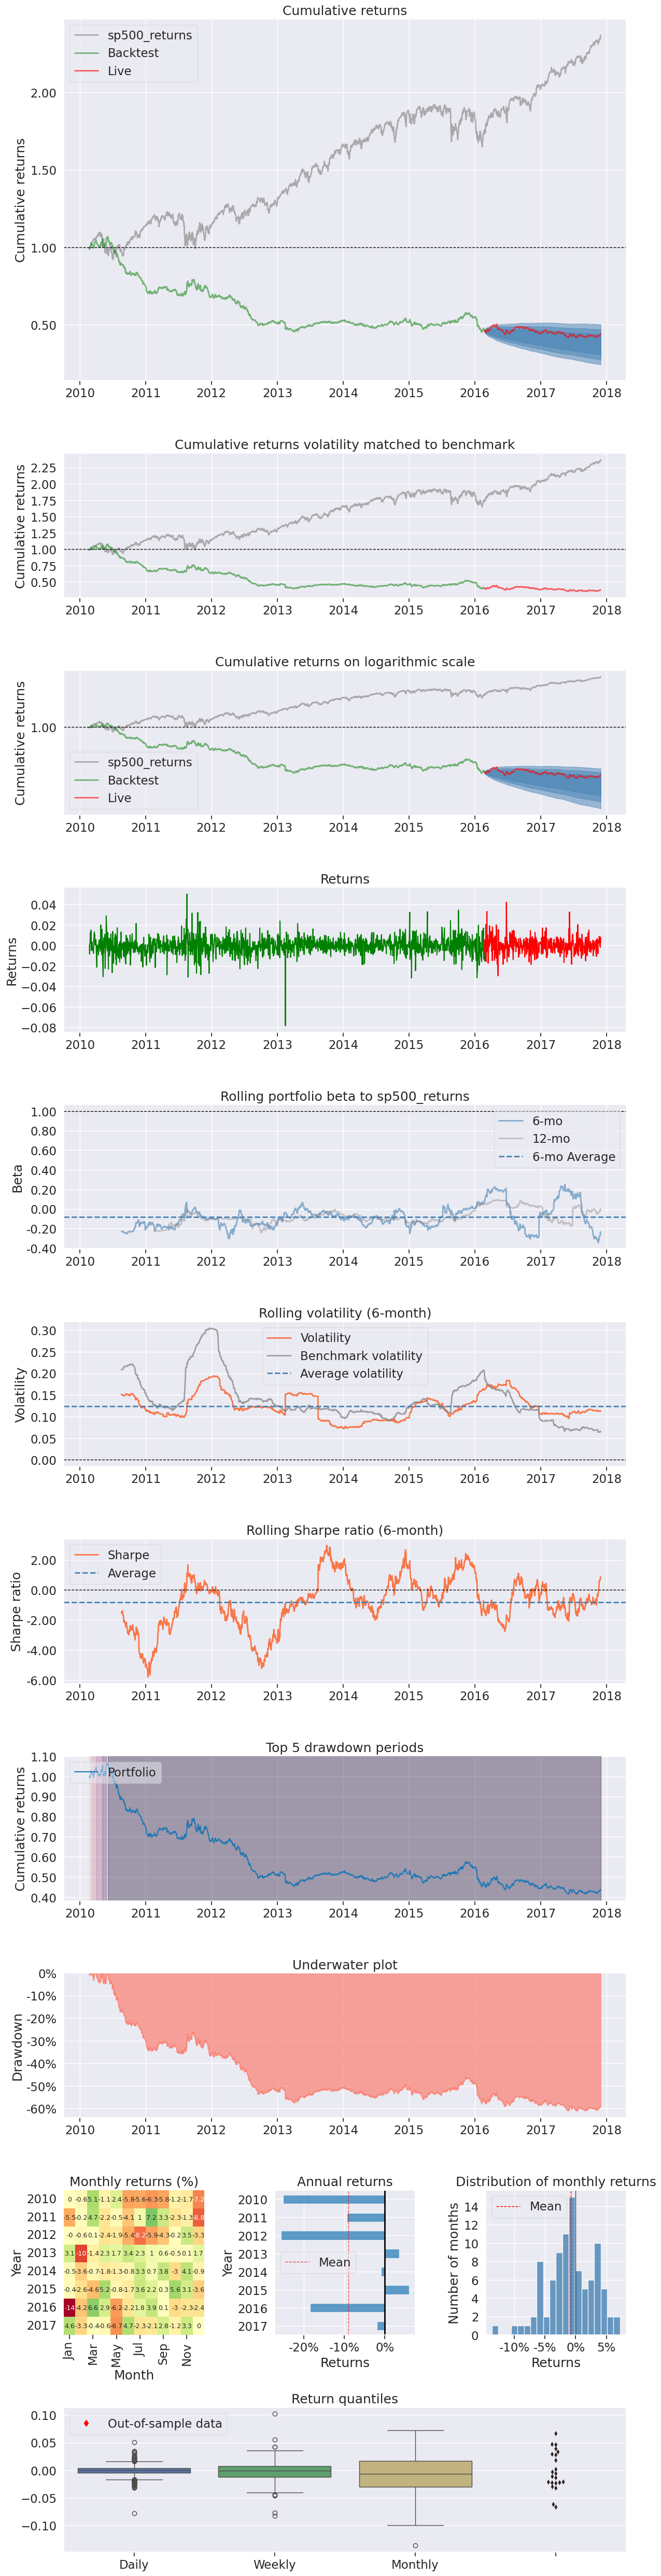

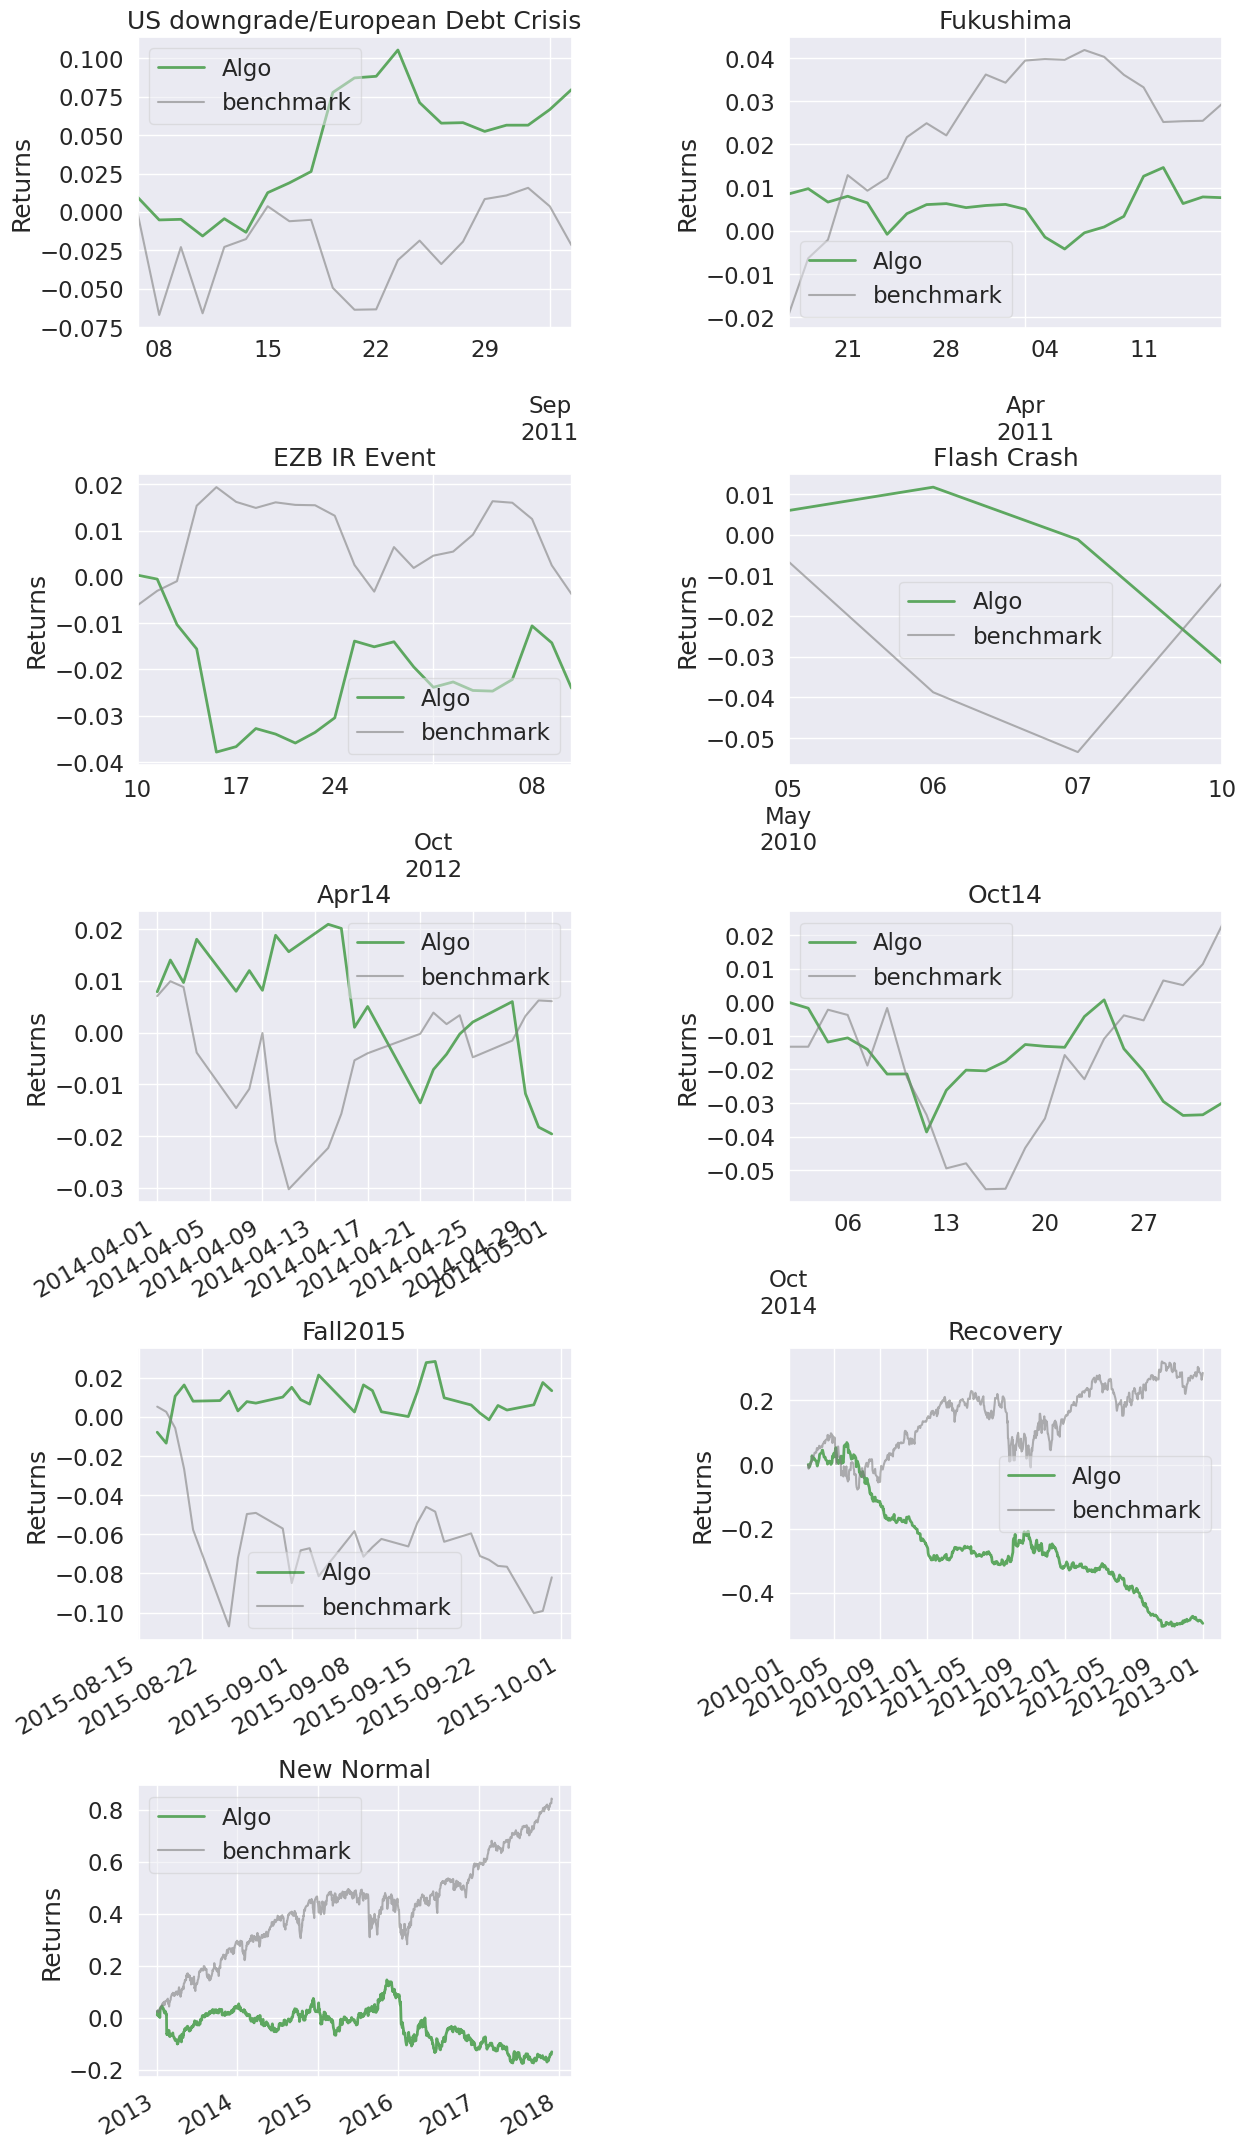

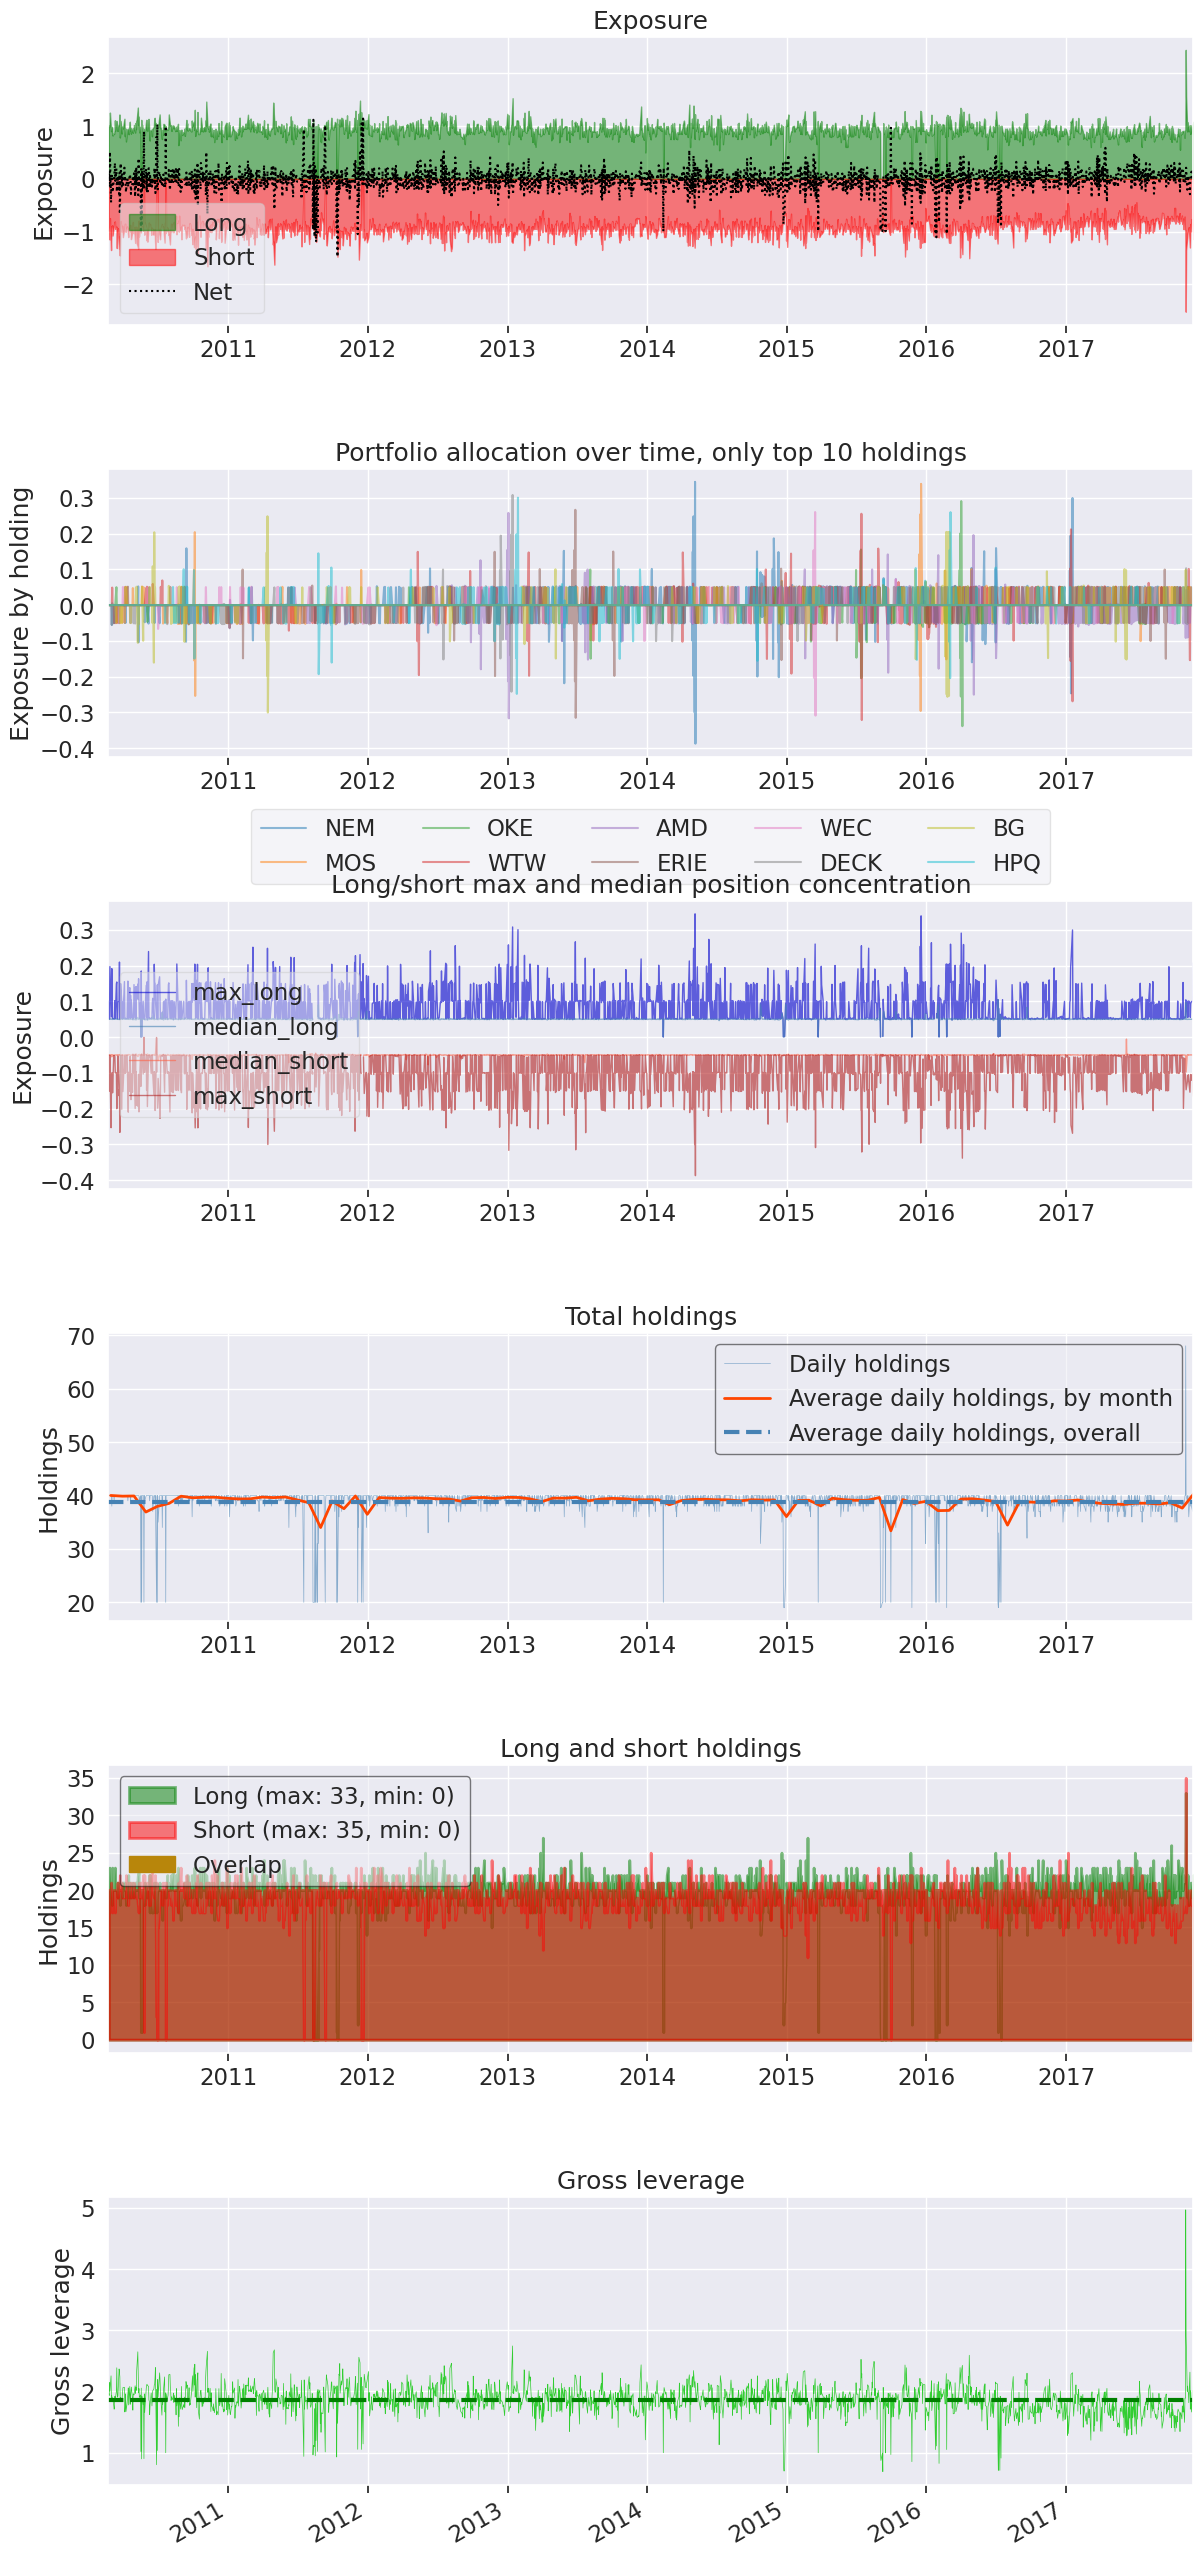

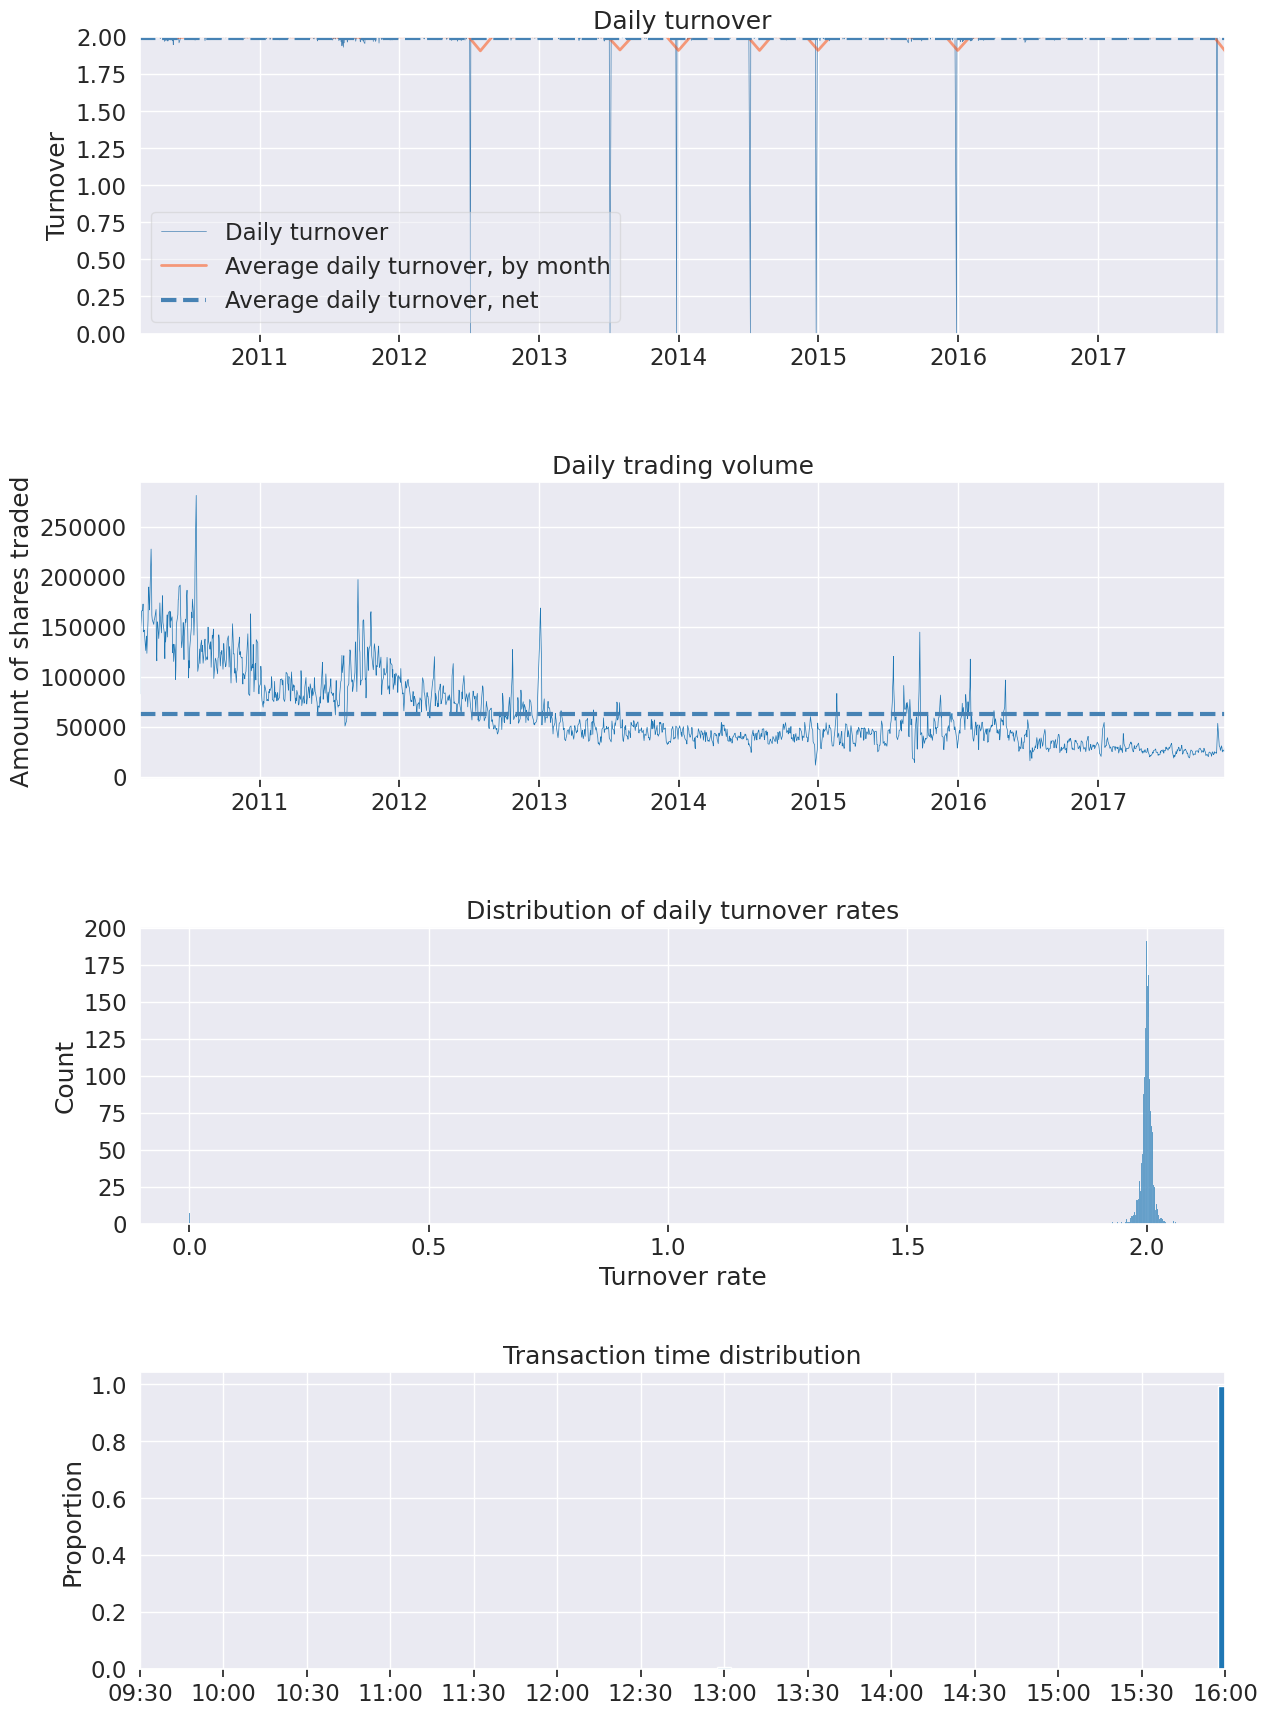

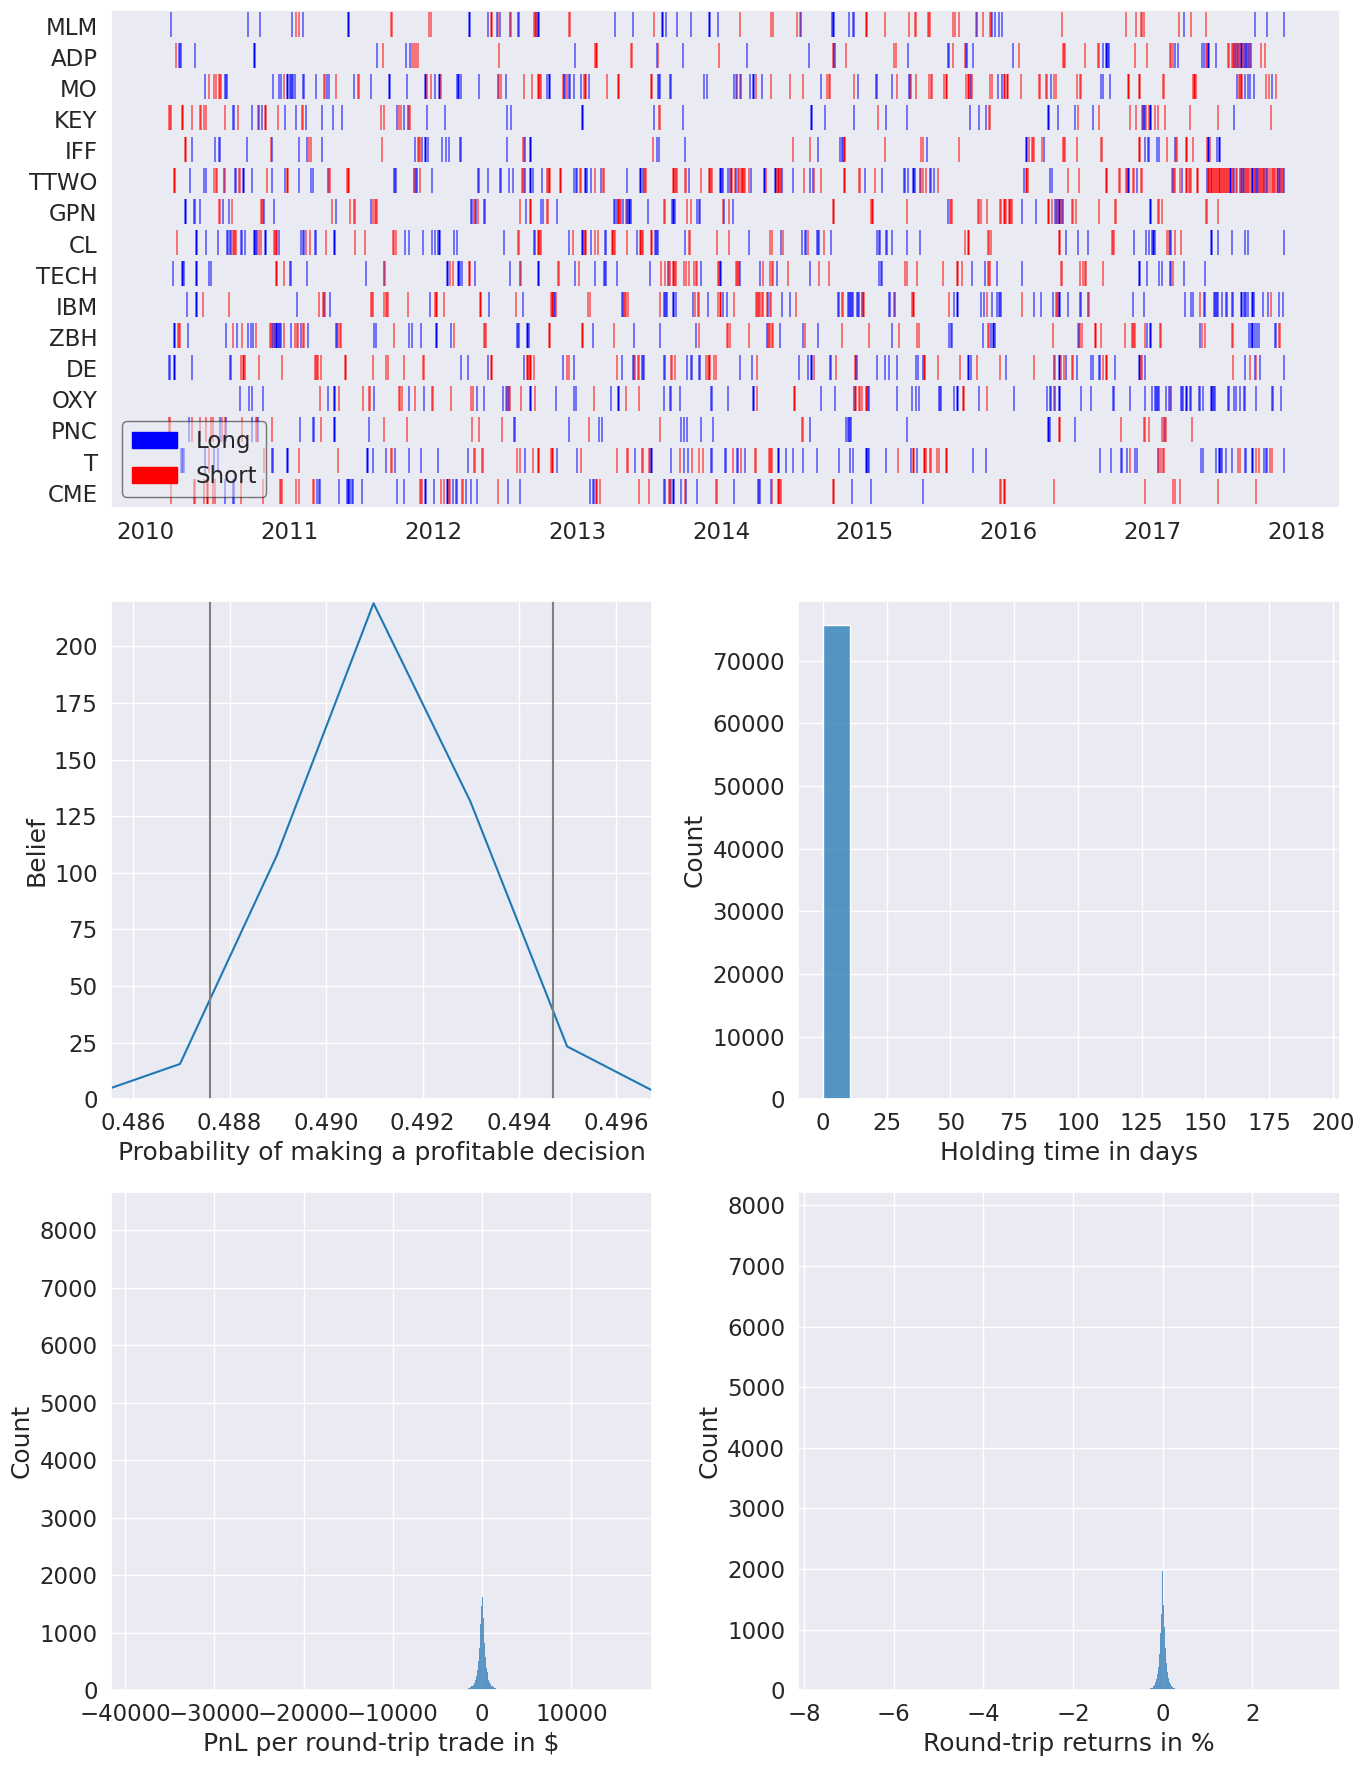

In [17]:
pf.create_full_tear_sheet(
    returns,
    transactions=transactions,
    positions=positions,
    live_start_date=LIVE_DATE,
    benchmark_rets=benchmark_data,
    round_trips=True
)

## Trading Strategy-II

### As seen in signal evaluations of the factors of the Ridge Model-16 (alpha=5000), we will long factors in quantile-3 and short factors in quantile-5

In [18]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":3,
        "quantile_short":5
    }
}

In [19]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=5,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.00,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge16_factor",
    trading_strategy=trading_strategy
)

In [20]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

#### Extracting Information from Zipline Results

In [21]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

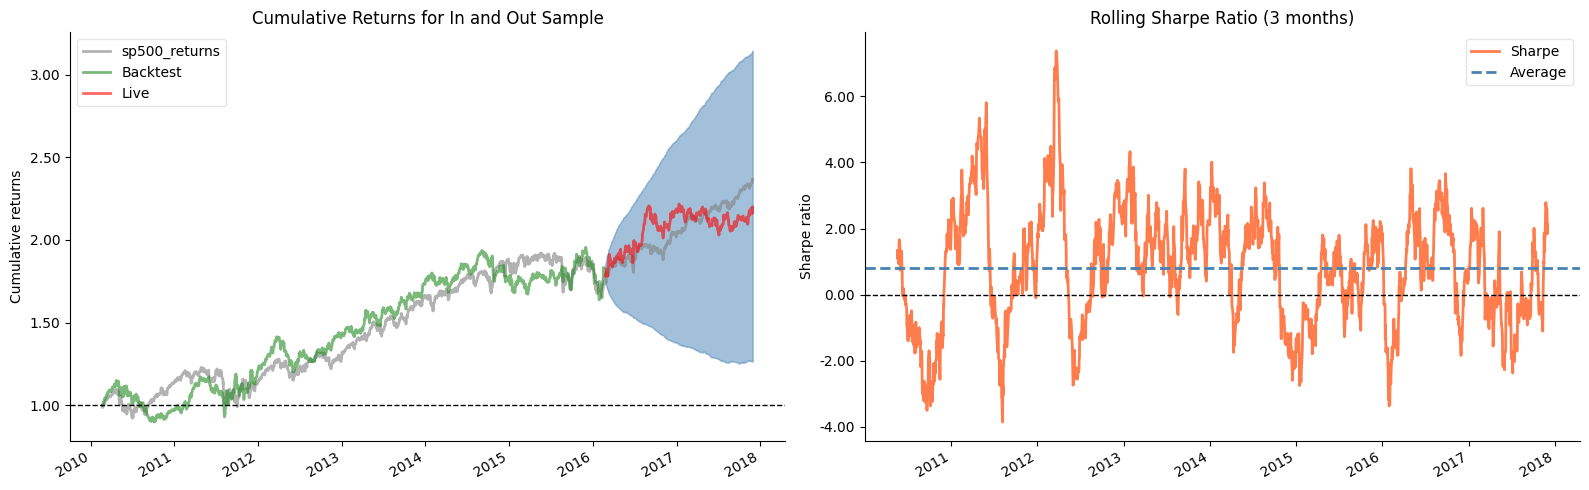

In [22]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,21.87,2010-04-23,2010-10-06,2011-04-21,260
1,20.77,2011-05-31,2011-08-08,2011-09-26,85
2,16.22,2015-12-02,2016-01-29,2016-05-24,125
3,15.01,2012-03-23,2012-06-01,2012-11-30,181
4,13.68,2014-09-05,2015-03-24,2015-11-30,322


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.39%,-6.91%,7.06%
Fukushima,0.29%,-1.07%,2.03%
EZB IR Event,0.05%,-1.62%,1.32%
Flash Crash,-0.20%,-3.30%,4.01%
Apr14,-0.02%,-1.82%,0.75%
Oct14,-0.24%,-2.38%,1.88%
Fall2015,-0.11%,-3.73%,3.37%
Recovery,0.06%,-6.91%,7.06%
New Normal,0.04%,-4.28%,3.38%


Top 10 long positions of all time,max
sid,
AES,28.78%
INCY,23.34%
DIS,22.87%
ARE,21.89%
BIIB,21.67%
LYV,20.27%
FOX,19.66%
DECK,19.60%
GPC,19.34%


Top 10 short positions of all time,max
sid,
AES,-24.27%
IPG,-21.71%
FICO,-21.32%
PNW,-21.28%
LEN,-20.75%
DVN,-20.44%
MRK,-20.32%
UHS,-20.00%
FFIV,-19.84%


Top 10 positions of all time,max
sid,
AES,28.78%
INCY,23.34%
DIS,22.87%
ARE,21.89%
IPG,21.71%
BIIB,21.67%
FICO,21.32%
PNW,21.28%
LEN,20.75%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$1077634.57,$-338518.97,$1416153.54
Gross profit,$22291771.37,$7083538.05,$15208233.31
Gross loss,$-21214136.79,$-7422057.02,$-13792079.77
Profit factor,$1.05,$0.95,$1.10
Avg. trade net profit,$22.85,$-23.60,$43.14
Avg. winning trade,$934.94,$1028.99,$896.76
Avg. losing trade,$-926.06,$-1009.39,$-886.67
Ratio Avg. Win:Avg. Loss,$1.01,$1.02,$1.01
Largest winning trade,$35358.11,$33867.36,$35358.11
Largest losing trade,$-48683.94,$-27692.71,$-48683.94


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 12:50:15.021453859,1 days 18:04:54.081480448,1 days 10:32:43.197355593
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,108 days 23:00:00,108 days 23:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 20:59:59


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,1.98%,1.98%,1.66%
Largest losing trade,-2.56%,-1.88%,-2.56%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.00%,0.00%,0.02%,0.01%,-0.01%,0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.01%,0.00%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,-0.01%,0.01%,-0.00%,-0.01%,0.02%,-0.00%,0.01%,-0.01%,0.00%,0.00%,0.00%,0.02%,-0.00%,0.00%,-0.00%,0.02%,0.01%,-0.01%,0.01%,0.01%,0.00%,-0.01%,0.01%,-0.00%,-0.01%,0.00%,0.00%,-0.00%,0.01%,0.00%,-0.01%,-0.02%,0.02%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,-0.01%,-0.02%,0.02%,-0.00%,-0.01%,0.00%,0.02%,-0.01%,0.00%,-0.00%,-0.00%,-0.02%,-0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.02%,-0.00%,0.01%,0.01%,0.00%,-0.02%,-0.00%,0.00%,0.01%,-0.01%,0.01%,0.00%,0.01%,0.01%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,0.00%,0.00%,0.02%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.01%,-0.00%,-0.02%,-0.00%,0.01%,0.01%,0.00%,0.03%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.02%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.02%,-0.00%,-0.01%,0.00%,0.01%,-0.01%,0.01%,0.01%,-0.00%,-0.01%,0.02%,0.01%,-0.01%,-0.01%,0.02%,-0.04%,0.01%,-0.01%,-0.00%,0.01%,0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.02%,-0.02%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.02%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.02%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.01%,-0.02%,-0.00%,0.01%,0.01%,0.01%,0.00%,0.01%,0.01%,-0.01%,0.00%,-0.01%,-0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.00%,0.01%,-0.01%,0.01%,-0.00%,-0.00%,-0.02%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,0.01%,-0.00%,0.02%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,0.02%,0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.01%,0.01%,0.01%,-0.01%,-0.00%,0.00%,-0.01%,0.01%,-0.01%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.01%,0.01%,0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.02%,0.01%,-0.01%,0.00%,0.01%,0.01%,-0.01%,0.00%,0.01%,0.01%,0.00%,-0.00%,-0.02%,0.00%,0.00%,0.00%,-0.01%,0.00%,0.02%,0.00%,0.02%,0.00%,0.01%,0.01%,0.02%,0.03%,0.01%,0.00%,0.02%,0.02%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.02%,-0.01%,-0.00%,0.01%,0.02%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.02%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.00%,0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.01%
Avg returns winning,0.06%,0.03%,0.06%,0.06

Profitability (PnL / PnL total) per name,
symbol,
VRTX,6.70%
HAL,6.18%
BBY,5.71%
CF,5.38%
BIIB,5.19%
TYL,4.78%
WDC,4.74%
FICO,4.50%
EQT,3.75%


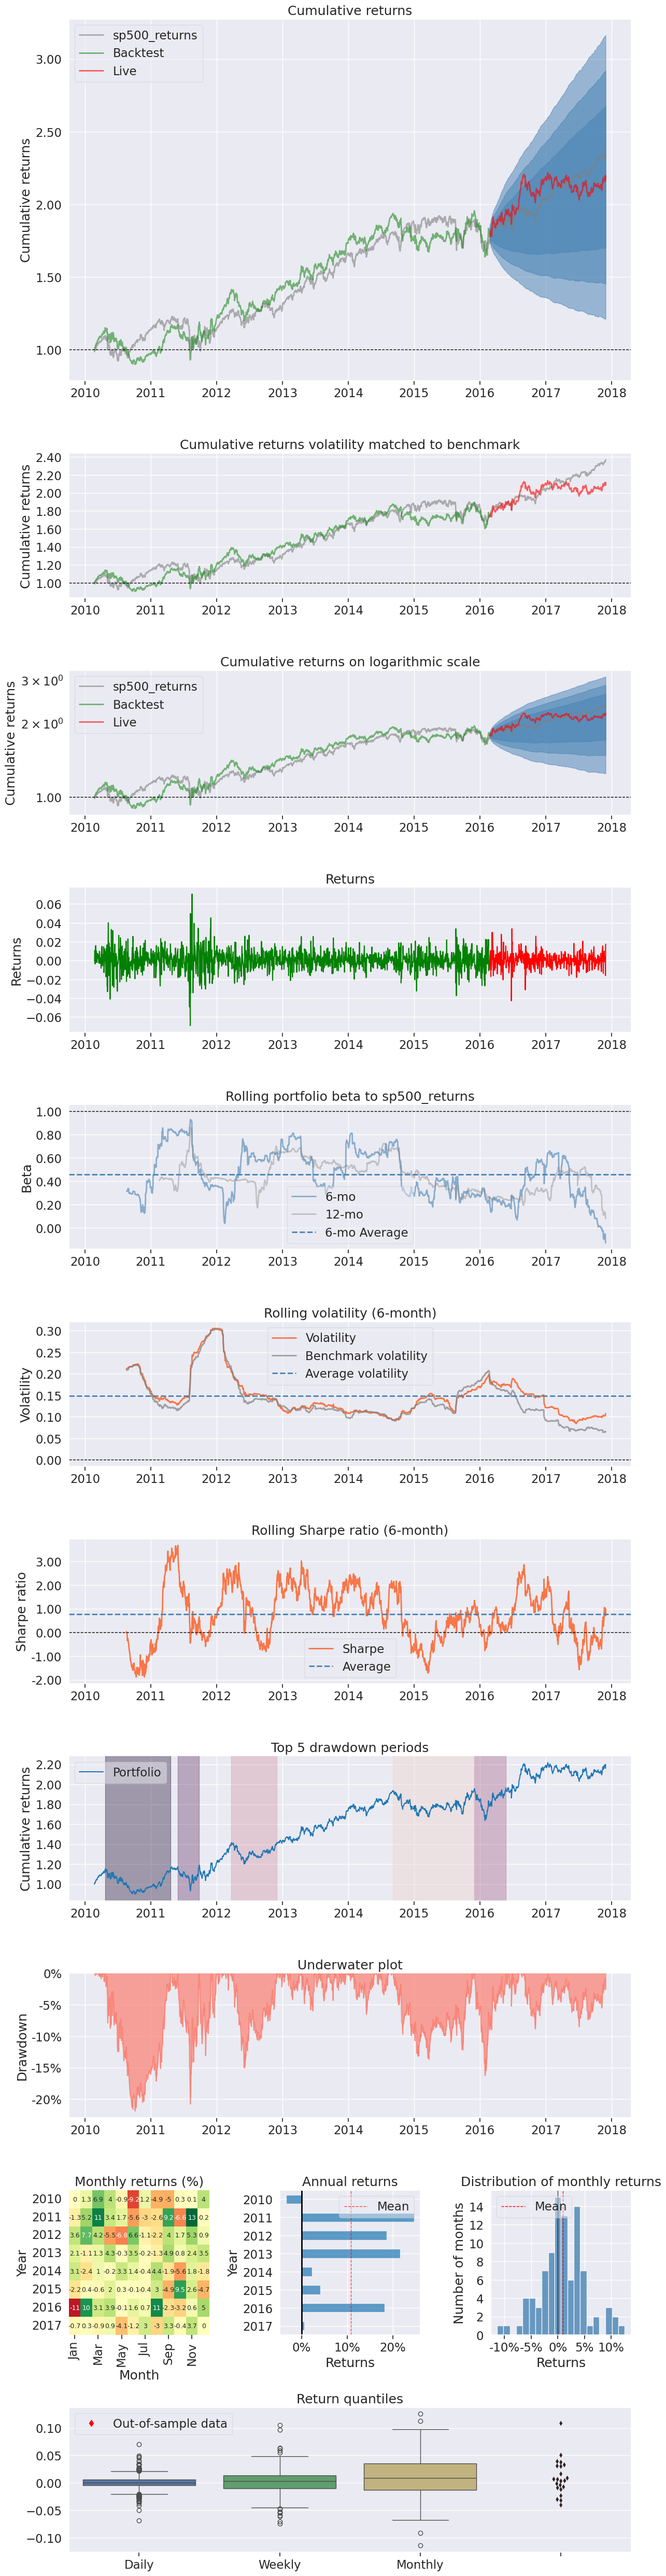

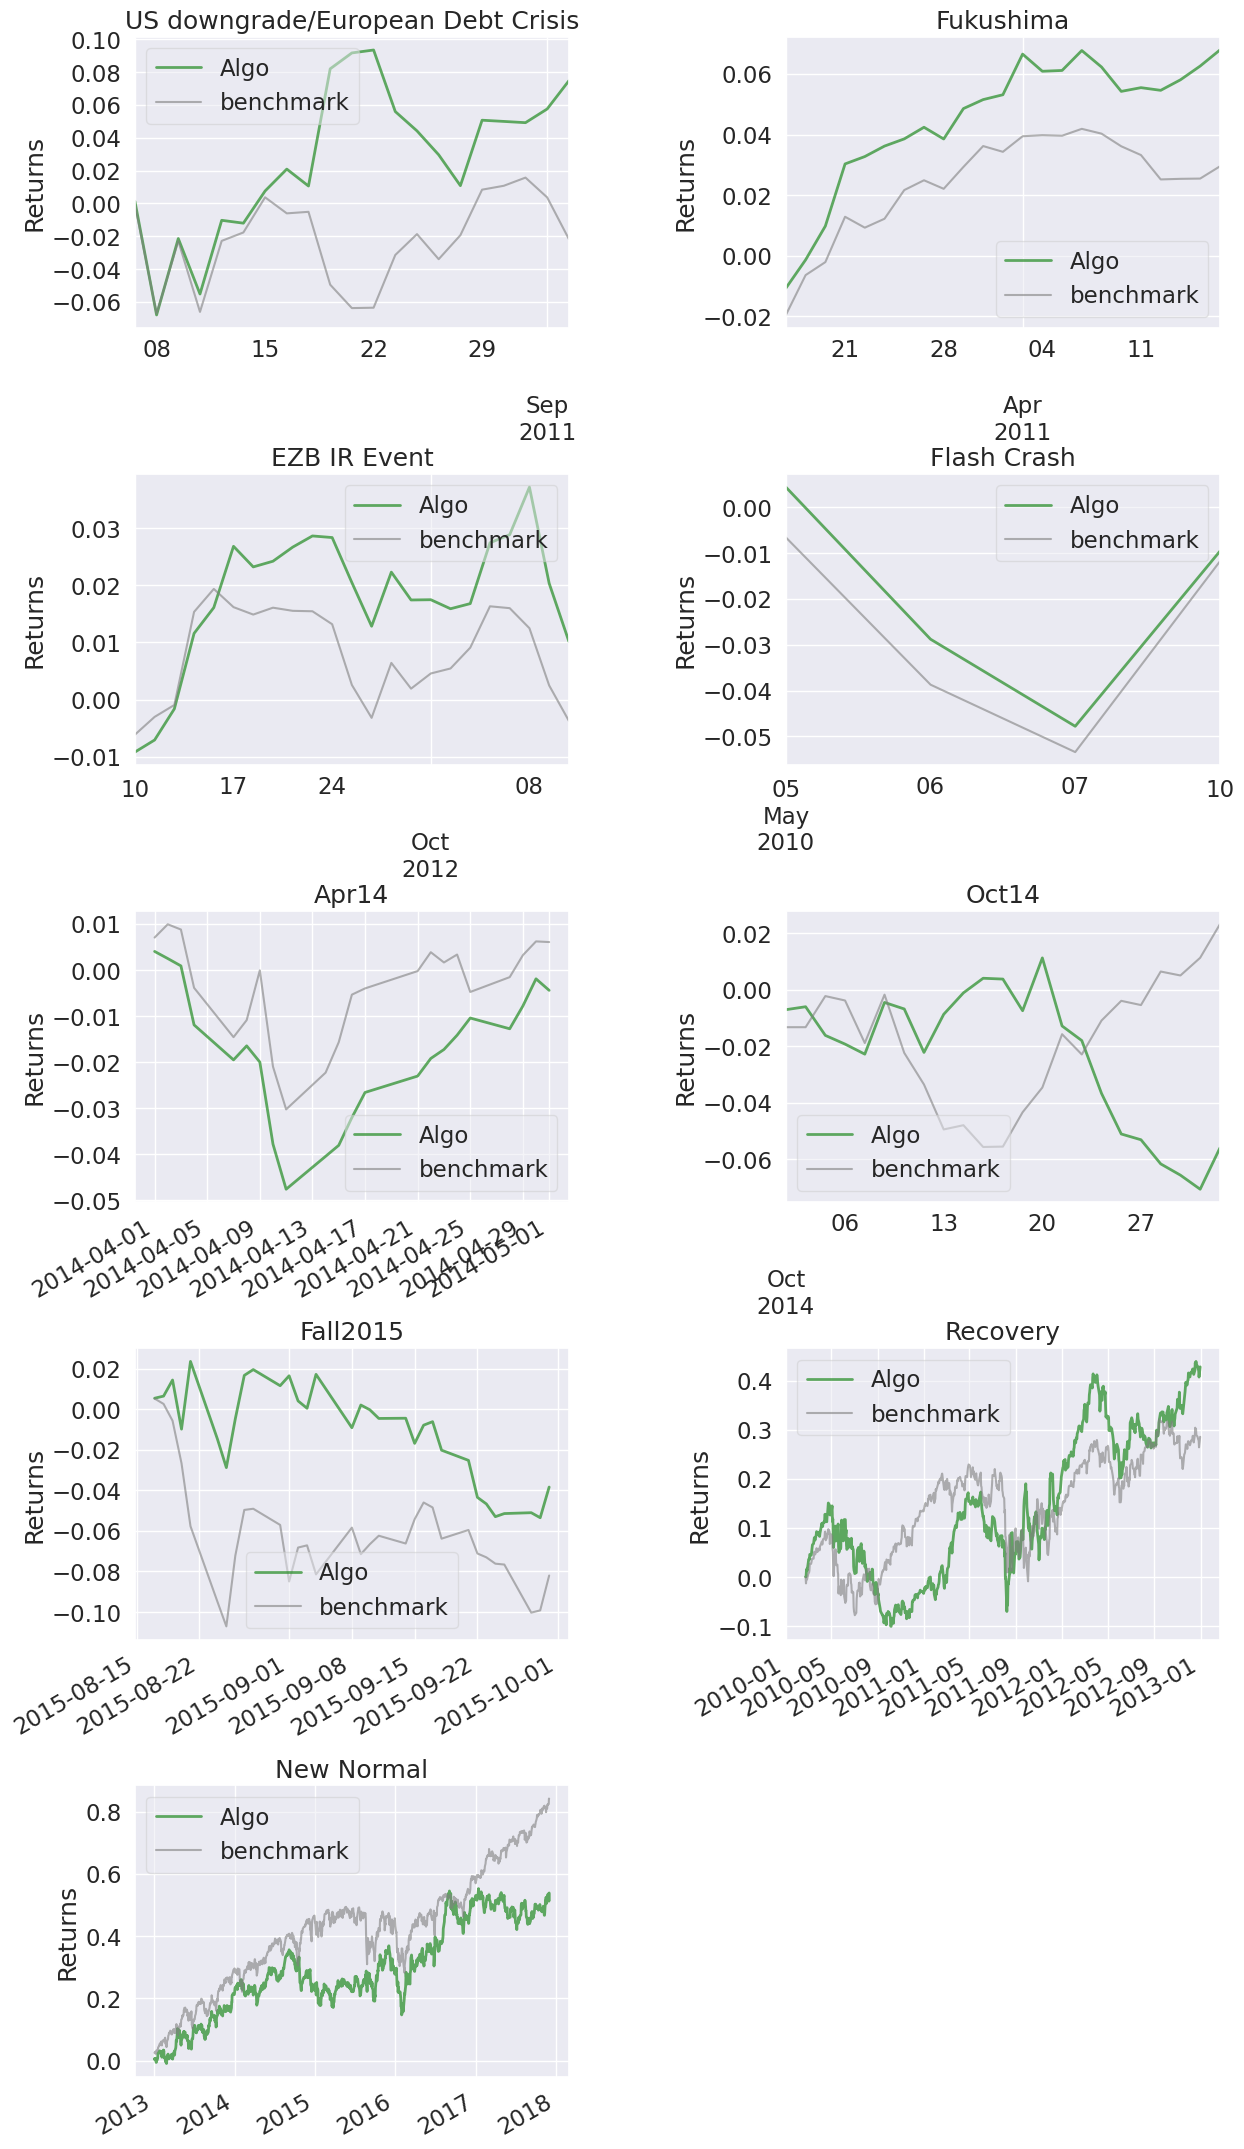

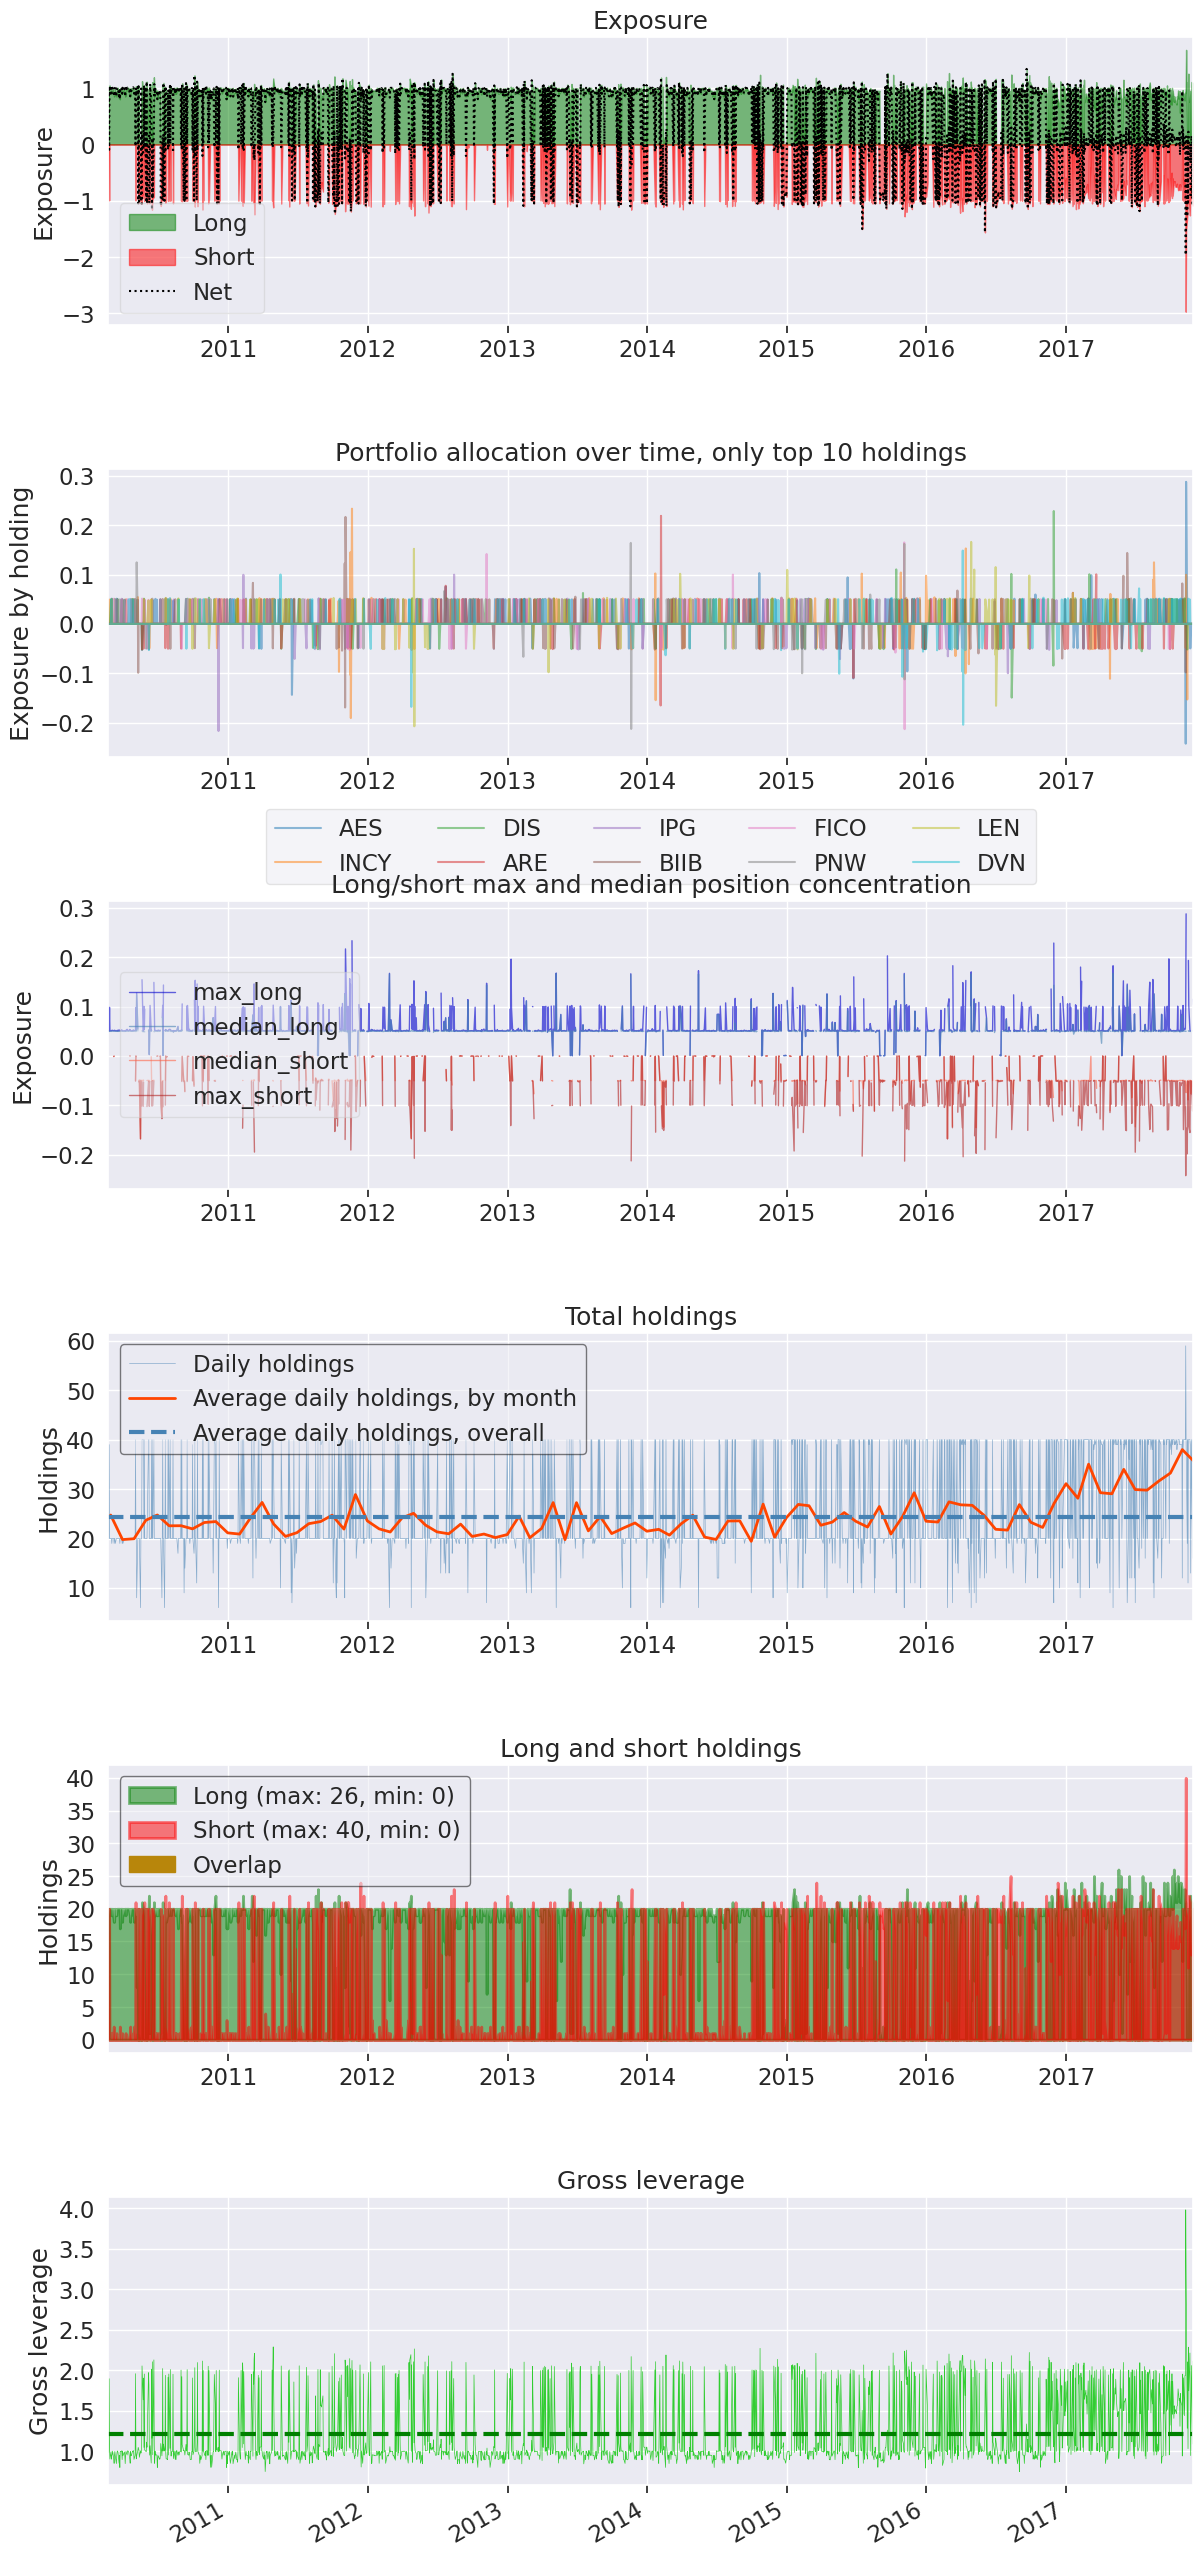

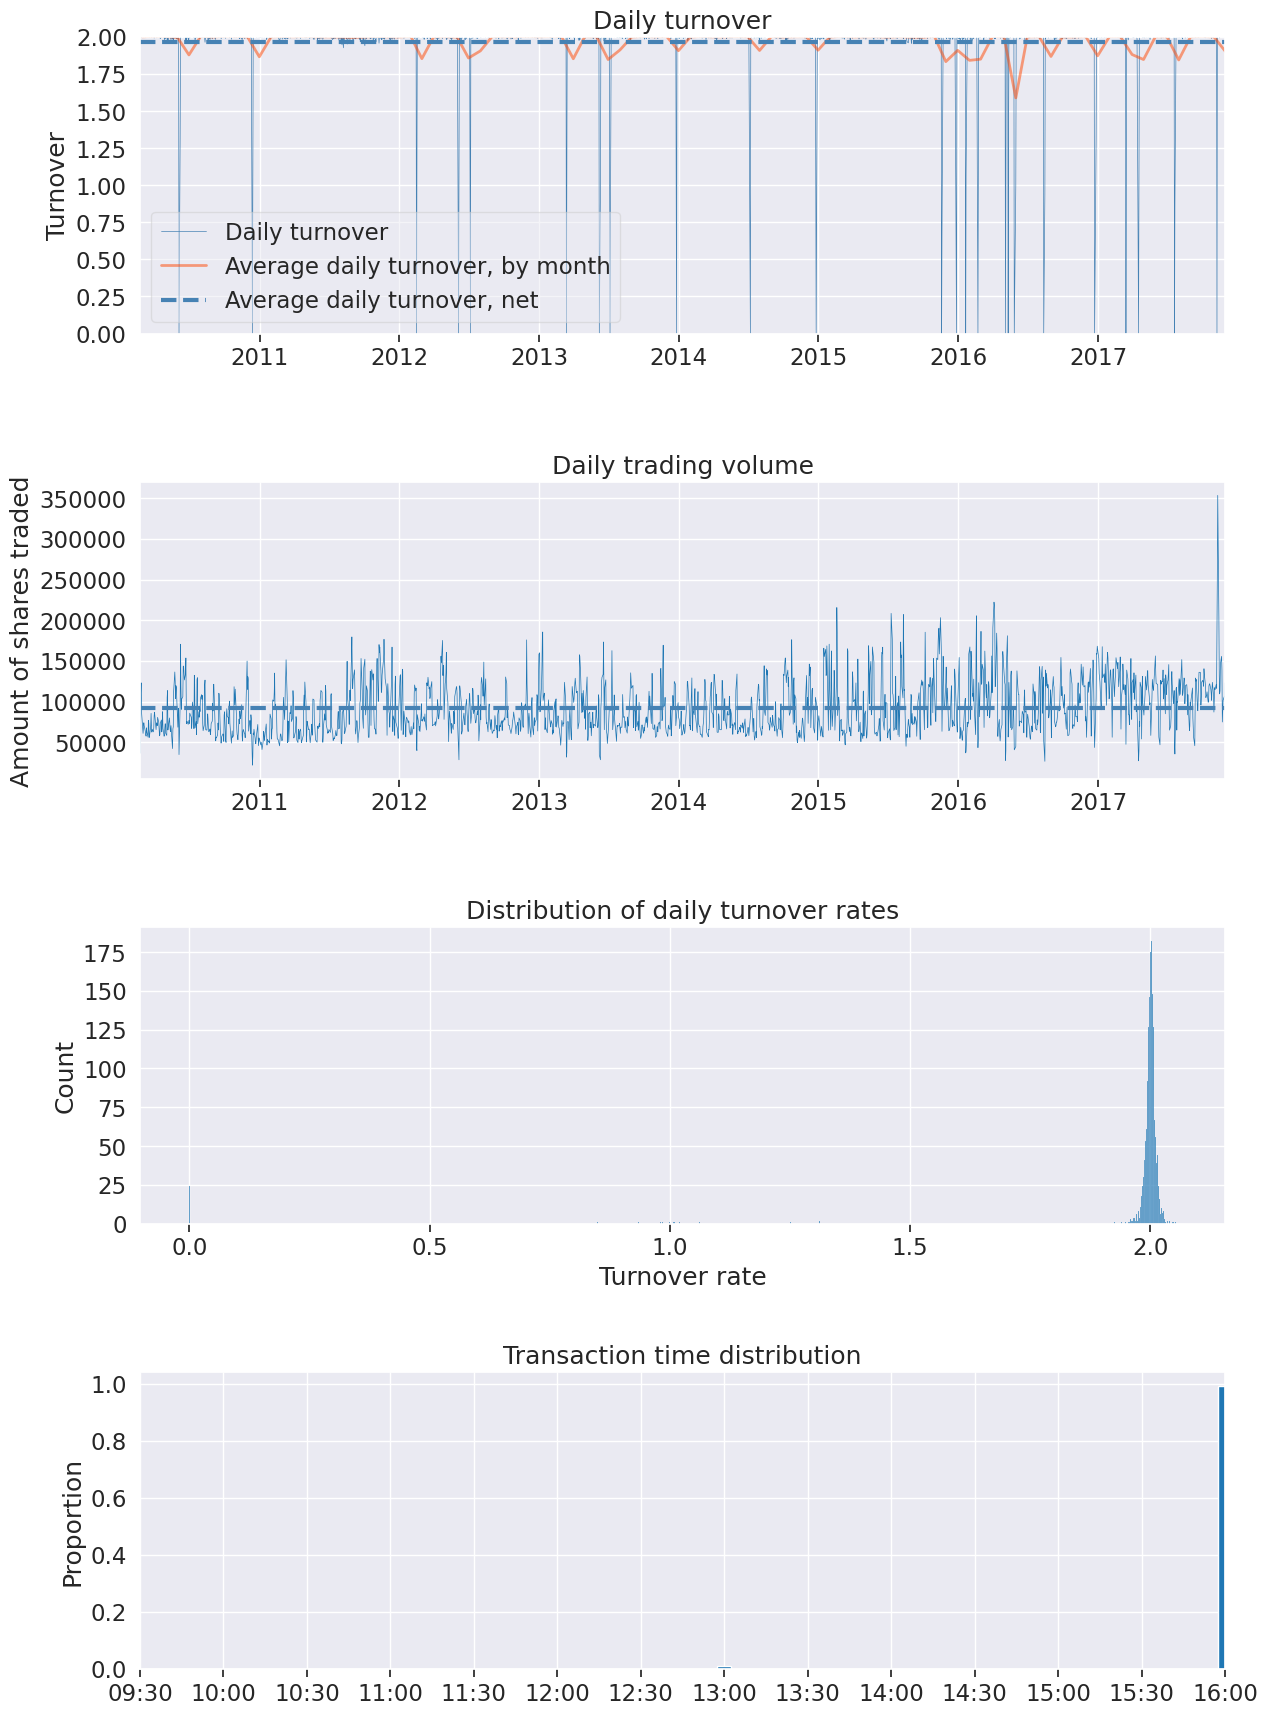

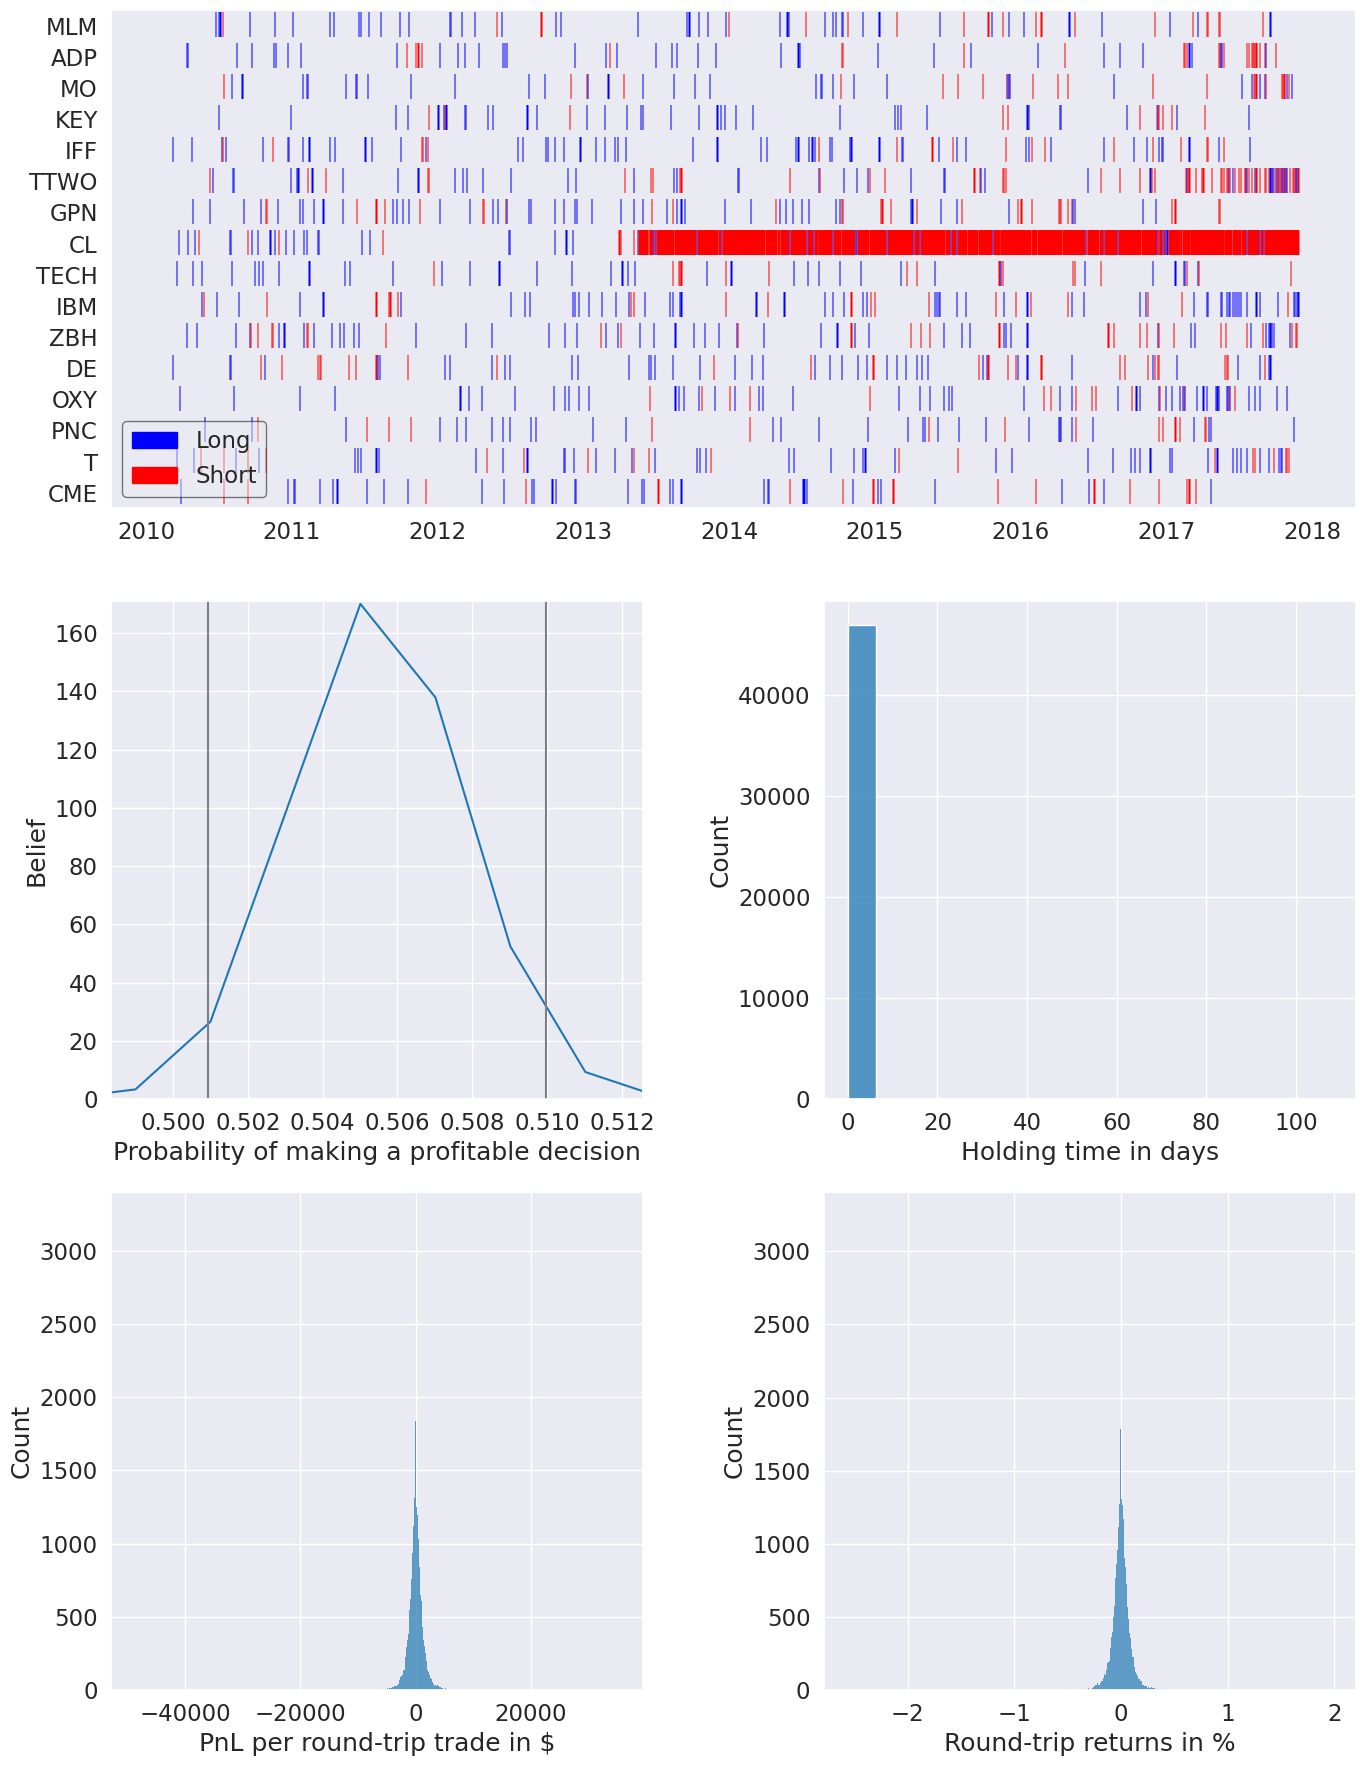

In [23]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)